In [74]:
#Se importan las librerías necesarias.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Aquí nos traemos los datos del dataframe.
df = pd.read_csv('Dataframe1.csv')
"""
Se crea una copia del dataset original (df_copy)
para conservar una versión sin modificar que permita
comparar los cambios realizados.
"""
df_copy = df.copy()

In [75]:
#Convertimos los datos que estén en formato fecha a Datetime.
df['rental_date'] = pd.to_datetime(df['rental_date'], errors='coerce')
df['return_date'] = pd.to_datetime(df['return_date'], errors='coerce')
df['payment_date'] = pd.to_datetime(df['payment_date'], errors='coerce')

In [76]:
#Vemos si hay nulls.
print(df.isnull().sum())

#Eliminamos los nulls de "rental_duration_days".
df['rental_duration_days'] = df['rental_duration_days'].dropna()

customer_id             0
first_name              0
last_name               0
email                   0
city                    0
country                 0
rental_id               0
rental_date             0
return_date             0
rental_duration_days    0
payment_id              0
amount                  0
payment_date            0
dtype: int64


In [77]:
#Vemos si hay duplicados.
print("Duplicados: ", df.duplicated().sum())

#Los eliminamos.
df = df.drop_duplicates()

Duplicados:  0


In [78]:
#Los datos que sean String, los ponemos en minúsculas y quitamos los espacios en blanco de los extremos.
df['city'] = df['city'].str.lower().str.strip()
df['country'] = df['country'].str.lower().str.strip()
df['first_name'] = df['first_name'].str.lower().str.strip()
df['last_name'] = df['last_name'].str.lower().str.strip()
df['first_name'] = df['first_name'].str.lower().str.strip()
df['email'] = df['email'].str.lower().str.strip()





In [79]:
#Convertir los datos numéricos en int o float dependiendo de si son números enteros o decimales.
df['amount'] = df['amount'].astype(float)
df['rental_duration_days'] = df['rental_duration_days'].astype(int)

count    1000.000000
mean        4.114000
std         2.338823
min         0.990000
25%         2.990000
50%         3.990000
75%         4.990000
max        10.990000
Name: amount, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

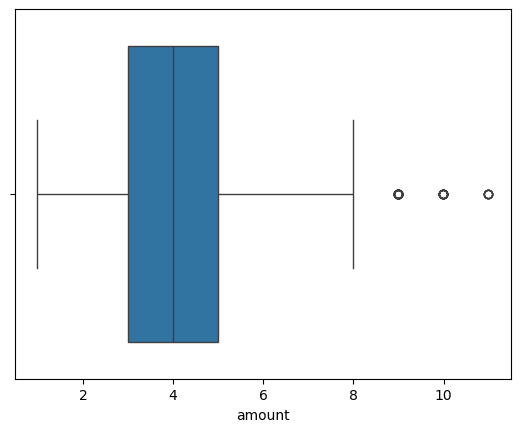

In [80]:
#Gráfica para identificar el outlier en la columna "amount".
print(df['amount'].describe())

sns.boxplot(x=df['amount'])
plt.show

In [81]:
#Crear una nueva columna que clasifique los registros de "amount" en high, medium o low.
def tipo_pago(pago):
  if pago > 5:
    return 'high'
  elif pago >= 3:
    return 'medium'
  else:
    return 'low'


df['amount_type'] = df['amount'].apply(tipo_pago)

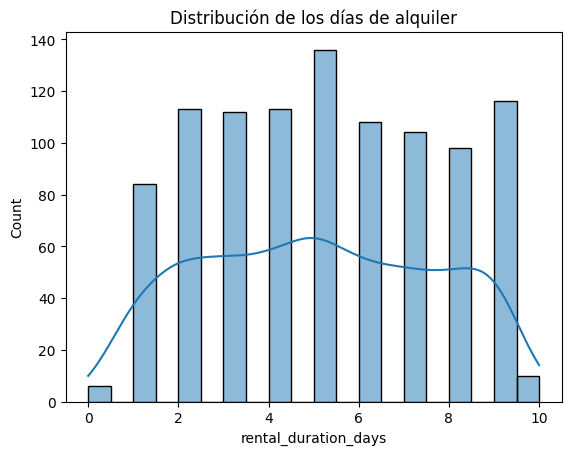

In [82]:
#Gráfica de los días de alquiler
sns.histplot(df['rental_duration_days'], bins=20, kde=True)
plt.title('Distribución de los días de alquiler')
plt.show()

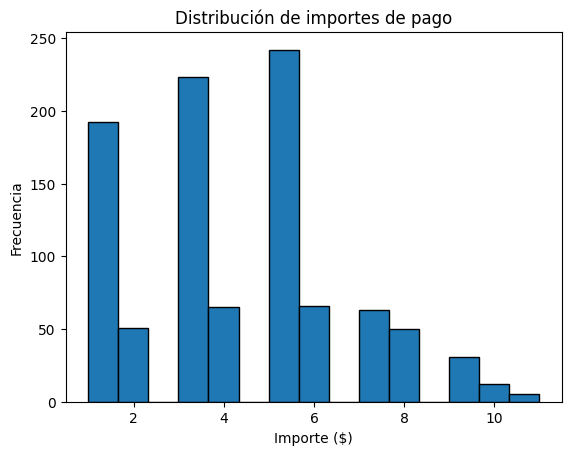

In [83]:
#Gráfica de la distribución de los importes de pago
plt.hist(df['amount'], bins=15, edgecolor='black')

plt.title('Distribución de importes de pago')

plt.xlabel('Importe ($)')

plt.ylabel('Frecuencia')

plt.show()

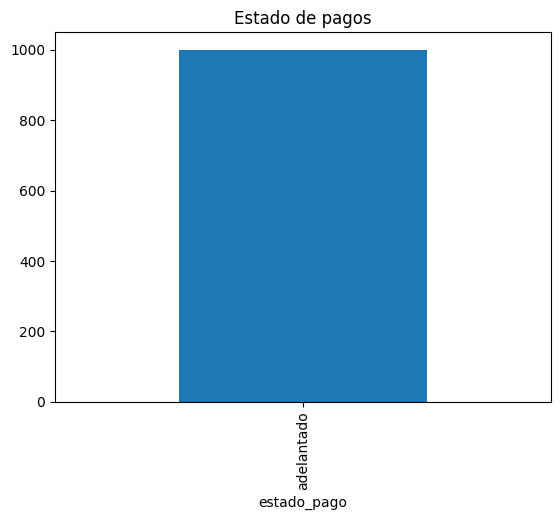

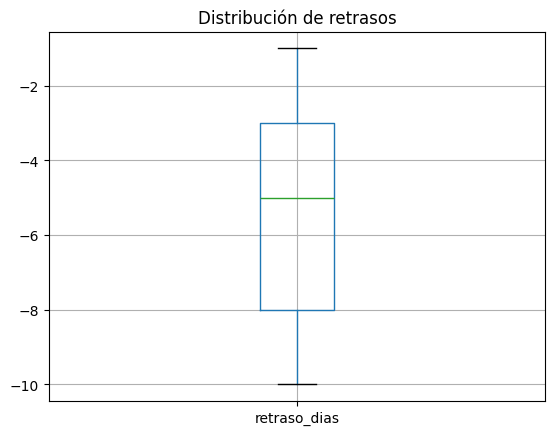

In [84]:
#Análisis de retrasos de pago: calculamos la diferencia entre la fecha de pago y la fecha esperada para identificar clientes que pagan adelantado,a tiempo o con retraso, y visualizar su comportamiento financiero.

# Calcular retraso
df['retraso_dias'] = (df['payment_date'] - df['return_date']).dt.days

# Clasificación
df['estado_pago'] = df['retraso_dias'].apply(
    lambda x: 'adelantado' if x < 0 else ('a tiempo' if x == 0 else 'tarde')
)

# Barra
df['estado_pago'].value_counts().plot(kind='bar')
plt.title("Estado de pagos")
plt.show()

# Boxplot (distribución de retrasos)
df.boxplot(column='retraso_dias')
plt.title("Distribución de retrasos")
plt.show()

In [85]:
#Exportar el dataframe con los datos ya limpios.
df.to_csv('dataframe_final.csv', index=False)